In [37]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal, List, Sequence, Annotated

In [38]:
class EmployeeState(TypedDict):
    name: str
    salary: float
    age: int
    decision: Literal["std_hr", "forced_hr"]
    result: str

In [39]:
def analyse_employee(state: EmployeeState) -> EmployeeState:
    age = state['age']
    salary = state['salary']
    if age <= 30 and salary <= 40000:
        state["decision"] = "standard_hr"
    else:
        state["decision"] = "forced_hr"
    print(f"le dossier de {state['name']} a été analysé")    
    return state

In [40]:
def standard_hr_process(state:EmployeeState):
    state['result'] = f"le dossier de {state['name']} a été traité de manière standard"
    print("*" *80)
    print (f"le dossier de {state['name']} a été traité de manière standard")
    print(f"Name: {state['name']} salary: {state['salary']} age: {state['age']}")
    print("*" *80)
    return state

In [41]:
def forced_hr_process(state:EmployeeState):
    state['result'] = f"le dossier de {state['name']} a été traité de manière forcée"
    print("=" *80)
    print (f"le dossier de {state['name']} a été traité de manière forcée")
    print(f"Name: {state['name']} salary: {state['salary']} age: {state['age']}")
    print("=" *80)
    return state

In [42]:
def router (state:EmployeeState):
    return state['decision']

In [43]:
workflow = StateGraph(EmployeeState)
workflow.add_node("analyze_node", analyse_employee)
workflow.add_node("standard_hr_node", standard_hr_process)
workflow.add_node("forced_hr_node", forced_hr_process)
workflow.add_edge(START, "analyze_node")
workflow.add_conditional_edges(
    "analyze_node",
    router, 
    {
        "standard_hr":"standard_hr_node",
        "forced_hr":"forced_hr_node"
    })
workflow.add_edge("standard_hr_node", END)
workflow.add_edge("forced_hr_node", END)

graph = workflow.compile()

In [44]:
from IPython.display import Image

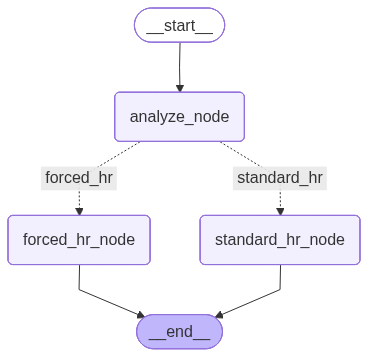

In [45]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [46]:
result = graph.invoke({
    "name": "mohamed",
    "age": 24,
    "salary": 20000
})

le dossier de mohamed a été analysé
********************************************************************************
le dossier de mohamed a été traité de manière standard
Name: mohamed salary: 20000 age: 24
********************************************************************************


In [47]:
print(result)

{'name': 'mohamed', 'salary': 20000, 'age': 24, 'decision': 'standard_hr', 'result': 'le dossier de mohamed a été traité de manière standard'}


In [48]:
result = graph.invoke({
    "name": "hajar",
    "age": 35,
    "salary": 30000
})

le dossier de hajar a été analysé
le dossier de hajar a été traité de manière forcée
Name: hajar salary: 30000 age: 35


In [49]:
print(result)

{'name': 'hajar', 'salary': 30000, 'age': 35, 'decision': 'forced_hr', 'result': 'le dossier de hajar a été traité de manière forcée'}


In [70]:
from langchain.tools import tool
from langchain.messages import SystemMessage, AIMessage, ToolMessage, HumanMessage
from langchain_core.messages import BaseMessage, AnyMessage
from langgraph.graph import add_messages
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import ToolNode
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [51]:
load_dotenv(override=True)

True

In [52]:
@tool
def add(a:float, b:float):
    """Add two numbers."""
    print(f"Adding {a} and {b}")
    return a+b

@tool
def multiply(a:float, b:float):
    """Multiply two numbers."""
    print(f"Multiplying {a} and {b}")
    return a*b

@tool
def divide(a:float, b:float):
    """Divide two numbers."""
    print(f"Dividing {a} by {b}")
    if b == 0:
        return "Error: Division by zero"
    return a/b    
    
tools = [add, multiply, divide]    

In [53]:
class AgentState(TypedDict):
    messages:Annotated[Sequence[BaseMessage], add_messages]

In [54]:
llm = ChatOpenAI(model="gpt-4o", temperature=0)
llm_with_tools = llm.bind_tools(tools=tools)

In [55]:
def assistant(state: AgentState) -> AgentState:
    response = llm_with_tools.invoke(state['messages'])
    
    print("-" * 50)    
    print("LLM invoked")
    
    return {
        "messages": [response]  
    }

In [56]:
def should_continue(state:AgentState) -> bool:
    last_message = state['messages'][-1]
    if not last_message.tool_calls:
        return "end"
    else:
        return "continue"        

In [71]:
workflow = StateGraph(AgentState)
workflow.add_node("assistant", assistant)
workflow.add_node("tools", ToolNode(tools=tools))
workflow.set_entry_point("assistant")
workflow.add_conditional_edges(
    "assistant",
    should_continue,
    {
        "end": END, 
        "continue": "tools"
    }
    )
workflow.add_edge("tools", "assistant")
memory = InMemorySaver()
graph = workflow.compile(checkpointer=memory)    

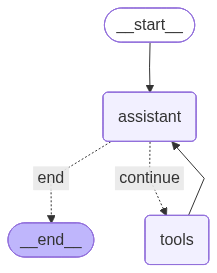

In [63]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [72]:
config = {"configurable": {"thread_id": "1"}}
resp = graph.invoke({
    "messages":[
        HumanMessage(content="Ajoute 2 et 3, puis multiplie le résultat par 4, et enfin divise le résultat par 2, et donne moi un proverbe en arabe"),
    ]
}, config=config)    

--------------------------------------------------
LLM invoked
Adding 2.0 and 3.0
Multiplying 5.0 and 4.0
Dividing 20.0 by 2.0
--------------------------------------------------
LLM invoked


In [68]:
print(resp['messages'][-1].content)

Le résultat final est 10.

Voici un proverbe en arabe : "الصبر مفتاح الفرج" qui signifie "La patience est la clé de la délivrance."


In [73]:
resp = graph.invoke({
    "messages":[
        HumanMessage("Bonjour, je m'appelle Hajar")
    ]
}, config=config)    
print(resp['messages'][-1].content)

--------------------------------------------------
LLM invoked
Bonjour Hajar ! Comment puis-je vous aider aujourd'hui ?


In [74]:
resp = graph.invoke({
    "messages":[
        HumanMessage("Comment je m'appelle ?")
    ]
}, config=config)    
print(resp['messages'][-1].content)

--------------------------------------------------
LLM invoked
Vous vous appelez Hajar.
